In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn: preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Scikit-learn: regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Scikit-learn: classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Scikit-learn: evaluation metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

#Scikit-learn: clustering & dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


3. Data Preprocessing & Feature Engineering

In [3]:

df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n')
df.head() # Print First 5 Rows


Dataset shape: 2240 rows × 29 columns



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

Columns with missing values:
Income    24
dtype: int64


In [8]:
#We build a master preprocessing function so the exact same pipeline applies consistently in every section
def preprocess(df_raw):
    """
    Master preprocessing pipeline.
    """
    df = df_raw.copy()

    # 3.1 Handle missing values_____
        # I used median because it ignores outliers like very high or very low incomes
    df['Income'] = df['Income'].fillna(df['Income'].median())

    # Handle outliers______
    # We use the IQR method to detect and remove outliers
    # IQR = the range between the 25th and 75th percentile (the middle 50% of data)
    # Any value too far above or below this range is considered an outlier

    outlier_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

    for col in outlier_cols:
     Q1  = df[col].quantile(0.25)   # value at 25% of the data
     Q3  = df[col].quantile(0.75)   # value at 75% of the data
     IQR = Q3 - Q1                  # the middle range

    # Any value below Q1-1.5×IQR or above Q3+1.5×IQR is an outlier
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Remove rows that fall outside these boundaries
    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f'Shape after outlier removal: {df.shape}')


    # 3.2 Feature engineering_______
    # Age from Year_Birth (assuming current year = 2026)
    df['Age'] = 2026 - df['Year_Birth']

    # TotalSpending = sum of all spending columns
    spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
    df['TotalSpending'] = df[spending_cols].sum(axis=1)

    # TotalChildren = kids at home + teenagers at home
    df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

    # 3.3 Filtering______
    # Remove unrealistic ages
    df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
    # Remove zero-income rows
    df = df[df['Income'] > 0]

    #3.4 Encode Education (ordinal)________
    edu_map = {'Basic': 0, 'Graduation': 1, '2n Cycle': 1,
               'Master': 2, 'PhD': 3}
    df['Education'] = df['Education'].map(edu_map)

    # 3.5 One-hot encode Marital_Status________
    # Keep top-4 categories; everything else → 'Other'
    top4 = df['Marital_Status'].value_counts().nlargest(4).index.tolist()
    df['Marital_Status'] = df['Marital_Status'].apply(
        lambda x: x if x in top4 else 'Other'
    )
    df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=False)

    #3.6 Drop columns not needed for modelling________
    drop_cols = ['ID', 'Year_Birth', 'Dt_Customer'] + spending_cols
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    return df


# Apply preprocessing
df_clean = preprocess(df)
print(f'Clean dataset shape: {df_clean.shape}')
df_clean.head()

Shape after outlier removal: (2033, 29)
Clean dataset shape: (2031, 27)


,Education,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,1,58138.0,0,0,58,3,8,10,4,7,...,11,1,67,1617,0,False,False,False,True,False
1,1,46344.0,1,1,38,2,1,1,2,5,...,11,0,70,27,2,False,False,False,True,False
2,1,71613.0,0,0,26,1,8,2,10,4,...,11,0,59,776,0,False,False,False,False,True
3,1,26646.0,1,0,26,2,2,0,4,6,...,11,0,40,53,1,False,False,False,False,True
4,3,58293.0,1,0,94,5,5,3,6,5,...,11,0,43,422,1,False,True,False,False,False


## 4. Supervised Learning — Regression

**Goal:** Predict TotalSpending (a continuous value) from customer features.

In [5]:
# ── Feature selection for regression ────────────────────────────────────────
# Drop the classification target and any leakage columns
reg_drop = ['TotalSpending', 'Response']
X_reg = df_clean.drop(columns=[c for c in reg_drop if c in df_clean.columns])
y_reg = df_clean['TotalSpending']

# Keep only numeric columns (safety check)
X_reg = X_reg.select_dtypes(include=[np.number])

#Train / test split (80 / 20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Feature scaling (fit on train only → transform both)
scaler_reg = StandardScaler()
X_train_r_sc = scaler_reg.fit_transform(X_train_r)
X_test_r_sc  = scaler_reg.transform(X_test_r)

print(f'Train size: {X_train_r_sc.shape[0]}  |  Test size: {X_test_r_sc.shape[0]}')

Train size: 1789  |  Test size: 448


In [6]:
# Train & evaluate all three regression models
reg_models = {
    'Linear Regression':          LinearRegression(),
    # alpha=0 → no penalty (same as Linear Regression)
    # alpha=1 → small, balanced penalty
    # alpha>1 → very strong penalty (model becomes too simple)
    # So We use alpha=1.0 because it gives a Good regularisation
    'Ridge Regression (α=1.0)':   Ridge(alpha=1.0),
    'Decision Tree (depth=5)':    DecisionTreeRegressor(max_depth=5, random_state=42)
}

reg_results = []

for name, model in reg_models.items():
    # Decision Tree does not need scaling but it doesn't hurt
    # Train the model using the scaled training data
    model.fit(X_train_r_sc, y_train_r)
    # Use the trained model to predict on the test data
    preds = model.predict(X_test_r_sc)

    mse  = mean_squared_error(y_test_r, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_r, preds)

    reg_results.append({'Model': name, 'MSE': round(mse, 2),
                        'RMSE': round(rmse, 2), 'R² Score': round(r2, 4)})

reg_df = pd.DataFrame(reg_results)
print('Regression Model Comparison')
print(reg_df.to_string(index=False))

Regression Model Comparison
                   Model      MSE   RMSE  R² Score
       Linear Regression 70608.26 265.72    0.8141
Ridge Regression (α=1.0) 70597.91 265.70    0.8142
 Decision Tree (depth=5) 56848.84 238.43    0.8503


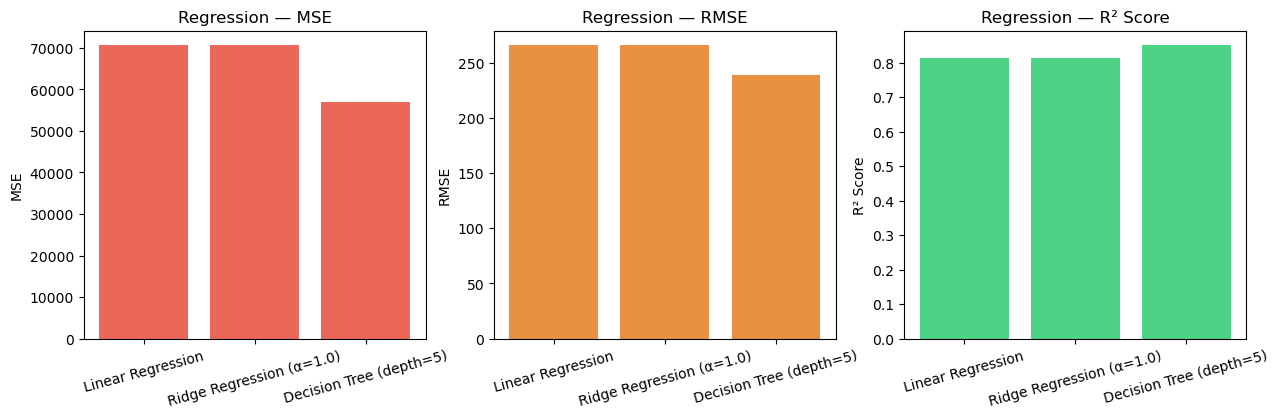

In [7]:
# ── Visualise regression results ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MSE', 'RMSE', 'R² Score']
colors  = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(reg_df['Model'], reg_df[metric], color=color, alpha=0.85)
    ax.set_title(f'Regression — {metric}', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
plt.show()


## 5. Supervised Learning — Classification

**Goal:** Predict Response — whether a customer accepted the last campaign (1) or not (0).

Class distribution (Response):


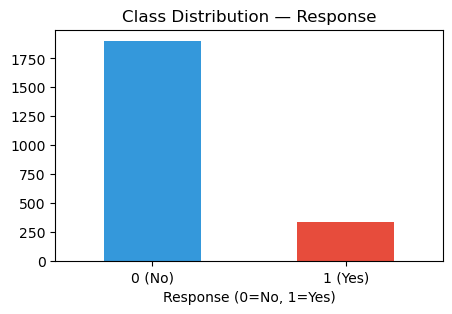

In [8]:
#Class distribution
print('Class distribution (Response):')
fig, ax = plt.subplots(figsize=(5, 3))
df_clean['Response'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c'], ax=ax)
ax.set_title('Class Distribution — Response')
ax.set_xlabel('Response (0=No, 1=Yes)')
ax.set_xticklabels(['0 (No)', '1 (Yes)'], rotation=0)
plt.show()

In [9]:
#Feature / target split
clf_drop = ['Response', 'TotalSpending']
X_clf = df_clean.drop(columns=[c for c in clf_drop if c in df_clean.columns])
y_clf = df_clean['Response']

X_clf = X_clf.select_dtypes(include=[np.number])

#Train / test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

#Scaling (fit on train only)
scaler_clf = StandardScaler()
X_train_c_sc = scaler_clf.fit_transform(X_train_c)
X_test_c_sc  = scaler_clf.transform(X_test_c)

print(f'Train: {X_train_c_sc.shape[0]}  |  Test: {X_test_c_sc.shape[0]}')

Train: 1789  |  Test: 448


In [10]:
# Define classifiers
# Logistic Regression and KNN use scaled data.
# Random Forest is tree-based and does not require scaling.

clf_models = {
    'Logistic Regression': {
         # class_weight='balanced' tells the model to pay more attention
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'scaled': True # Logistic Regression is sensitive to feature size so it is needs scaling
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'scaled': True # KNN measures distances so there are big numbers dominate so it must scale
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        'scaled': False  
    }
}

clf_results = []

for name, cfg in clf_models.items():
    Xtr = X_train_c_sc if cfg['scaled'] else X_train_c.values
    Xte = X_test_c_sc  if cfg['scaled'] else X_test_c.values

    cfg['model'].fit(Xtr, y_train_c)
    preds = cfg['model'].predict(Xte)

    clf_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_c, preds), 4),
        # Precision of all predicted yes, how many were actually yes
        'Precision': round(precision_score(y_test_c, preds, zero_division=0), 4),
        # Recall of all actual yes, how many did we catch
        'Recall':    round(recall_score(y_test_c, preds, zero_division=0), 4),
         # F1-Score  balance between Precision and Recall (best metric here)
        'F1-Score':  round(f1_score(y_test_c, preds, zero_division=0), 4),
        'preds':     preds   # store for confusion matrices
    })
# Convert results list into a dataframe table (drop preds column, it's only for plots)
clf_df = pd.DataFrame(clf_results).drop(columns='preds')
print('Classification Model Comparison')
print(clf_df.to_string(index=False))

Classification Model Comparison
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7924     0.4015  0.7910    0.5327
K-Nearest Neighbors    0.8728     0.6316  0.3582    0.4571
      Random Forest    0.8884     0.7429  0.3881    0.5098


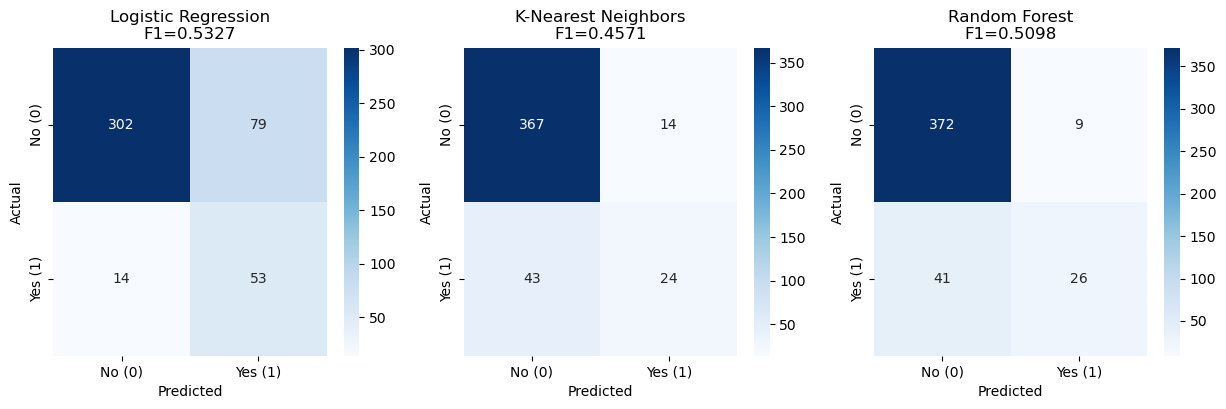

In [11]:
# ── Confusion matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, result in zip(axes, clf_results):
    cm = confusion_matrix(y_test_c, result['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    ax.set_title(f"{result['Model']}\nF1={result['F1-Score']}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.show()

In [12]:
# ── Full classification reports ──────────────────────────────────────────────
for result in clf_results:
    print(classification_report(y_test_c, preds, target_names=['No Response','Responded']))

              precision    recall  f1-score   support

 No Response       0.90      0.98      0.94       381
   Responded       0.74      0.39      0.51        67

    accuracy                           0.89       448
   macro avg       0.82      0.68      0.72       448
weighted avg       0.88      0.89      0.87       448

              precision    recall  f1-score   support

 No Response       0.90      0.98      0.94       381
   Responded       0.74      0.39      0.51        67

    accuracy                           0.89       448
   macro avg       0.82      0.68      0.72       448
weighted avg       0.88      0.89      0.87       448

              precision    recall  f1-score   support

 No Response       0.90      0.98      0.94       381
   Responded       0.74      0.39      0.51        67

    accuracy                           0.89       448
   macro avg       0.82      0.68      0.72       448
weighted avg       0.88      0.89      0.87       448



For **imbalanced classification** (predicting campaign responders), **F1-Score** is the most important metric because:
- The dataset has ~85% class-0 (no response) vs ~15% class-1 (response).
- A naive model predicting all-0 gets ~85% accuracy but 0% recall on responders.


---
## 6. Unsupervised Learning — Clustering
**Goal:** Segment customers by `TotalSpending`, `Income`, `Age`, `TotalChildren`.
### Approach
1. Select & scale the Four features.
2. Use the Elbow Method to find optimal k.
3. Fit K-Means, add cluster labels.
4. Visualise with PCA.
5. Profile each cluster.

In [13]:
# Select & scale clustering features
cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = df_clean[cluster_features].copy()

scaler_clust = StandardScaler()
X_cluster_sc = scaler_clust.fit_transform(X_cluster)

print(f'Clustering matrix shape: {X_cluster_sc.shape}')

Clustering matrix shape: (2237, 4)


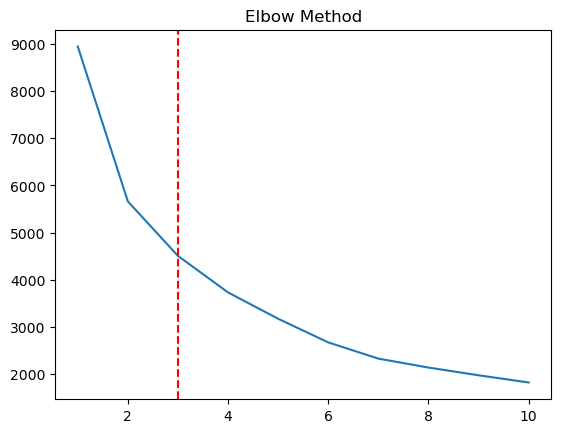

The elbow bends at k=3 — inertia drops sharply up to 3, then levels off. Choosing k=3 balances simplicity and cluster quality.


In [14]:
# Elbow Method: inertia vs k
inertia_vals = []
# We will test k from 1 to 10 clusters
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Train the model on the scaled clustering data
    km.fit(X_cluster_sc)
    inertia_vals.append(km.inertia_)

# We are looking for the "elbow" the point where inertia stops dropping fast
plt.plot(range(1, 11), inertia_vals)
plt.title('Elbow Method')
# Draw a red vertical line at k=3 to mark our chosen number of clusters
plt.axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
plt.show()

#The elbow bends at k=3  inertia drops sharply up to 3, then levels off. Choosing k=3 balances simplicity and cluster quality.

print('The elbow bends at k=3 — inertia drops sharply up to 3,'
      ' then levels off. Choosing k=3 balances simplicity and cluster quality.')

In [15]:
# ── Fit K-Means with k=3 ────────────────────────────────────────────────────
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster_sc)

print('Cluster label counts:')
print(df_clean['Cluster'].value_counts().sort_index())

Cluster label counts:
Cluster
0    710
1    796
2    731
Name: count, dtype: int64


Explained variance ratio: PC1=49.99%, PC2=26.98%


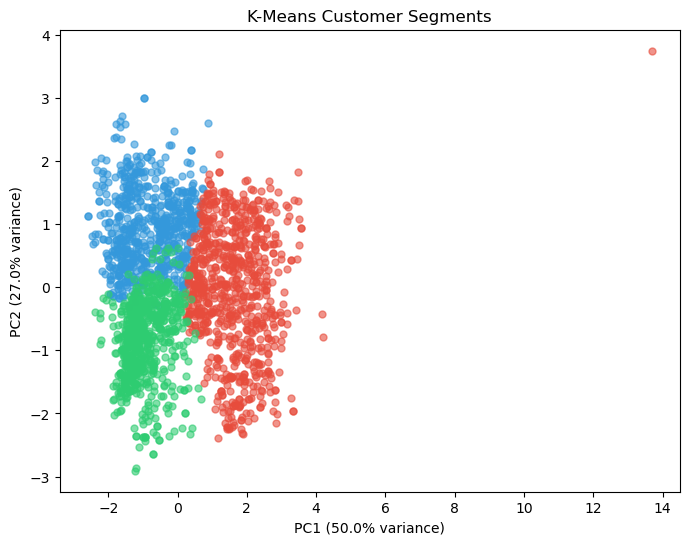

In [16]:
# PCA: reduce to 2D for visualisation
# PCA reduces our 4 features (Income, Age, TotalSpending, TotalChildren)
# we  take just 2 numbers (PC1, PC2) so we can plot them on a 2D chart
# n_components=2 means we want 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.2%}')

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_clean['Cluster'].values

# Define a colour for each cluster (blue, red, green)
palette = {0: '#3498db', 1: '#e74c3c', 2: '#2ecc71'}
# Define a display name for each cluster in the legend
labels  = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

# Loop through each cluster and plot its points separately
# This way each cluster gets its own colour and legend entry
plt.figure(figsize=(8, 6))
for cl in range(OPTIMAL_K):
    mask = pca_df['Cluster'] == cl
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=palette[cl], label=labels[cl], alpha=0.6, s=25)
    
# e.g. PC1=50%, PC2=27% means our 2D plot captures 77% of the data

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means Customer Segments')
plt.show()


Cluster Mean Profile
         TotalSpending   Income   Age  TotalChildren
Cluster                                             
0                298.5  47278.9  61.9            1.7
1               1289.3  74150.2  56.6            0.4
2                159.8  33161.6  46.8            0.8


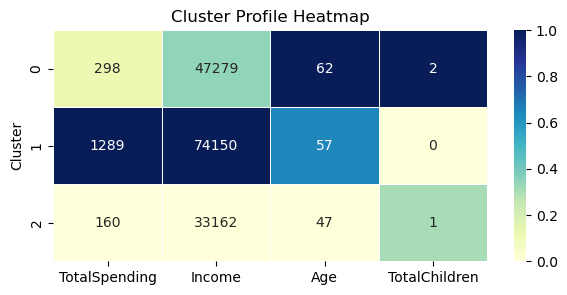

In [17]:
# ── Cluster profiling ────────────────────────────────────────────────────────
# Group customers by their cluster label
# then calculate the average Income, Age, TotalSpending, TotalChildren
profile = df_clean.groupby('Cluster')[cluster_features].mean().round(1)
print('Cluster Mean Profile')
print(profile)

# Visual heatmap of cluster profiles
# Normalise the values to a 0-1 scale so colours are comparable across features
# Without this, for example Income (50,000) would always look "hot" vs Age just because
# the numbers are on completely different scales
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
plt.figure(figsize=(7, 3))
sns.heatmap(profile_norm, annot=profile.values, fmt='.0f',
            cmap='YlGnBu', linewidths=0.5)
plt.title('Cluster Profile Heatmap')
plt.show()

## Summary

| Section | Best Model | Key Metric |
|---------|-----------|------------|
| Regression | Decision Tree / Ridge | R² Score |
| Classification | Random Forest | F1-Score (imbalanced) |
| Clustering | K-Means (k=3) | Elbow Inertia |

**Key takeaways:**
- Ridge Regression : When features are correlated, Linear Regression assigns huge unstable coefficients which causes overfitting.
 Ridge fixes this by adding a penalty that forces the coefficients to stay small
- Random Forest handles class imbalance better than KNN due to the `class_weight='balanced'` option and ensemble robustness.
- Three customer segments emerge clearly, useful for targeted marketing campaigns.